<a href="https://colab.research.google.com/github/RoAr29/ecommerce-recommendation-system/blob/main/ecommerce_product_recommendation_engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

git add .  
git commit -m "Describe what you did today"  
git push

##Build a hybrid recommendation engine that:

Personalizes for different customer segments

Balances exploitation and exploration

Simulates revenue impact

Visualizes insights in Power BI

##System Architecture:  
Transactional Data  
        ↓   
RFM Segmentation  
        ↓  
Recommendation Models(Popularity, CF, Hybrid)  
↓  
Diversity & Bias Evaluation  
        ↓  
Exploration Strategy Layer  
        ↓  
Revenue Simulation  
        ↓  
Power BI Dashboard


## Exploratory Data Analysis Insights
- Customer revenue distribution
- Product popularity analysis
- Long tail marketplace pattern

In [2]:
import pandas as pd

df = pd.read_excel("online_retail_II.xlsx", sheet_name=0)
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [3]:
df.shape

(525461, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [5]:
df['Customer ID'].nunique()

4383

In [6]:
df['StockCode'].nunique()

4632

In [7]:
df['InvoiceDate'].min(), df['InvoiceDate'].max() #shows time range of dataset

(Timestamp('2009-12-01 07:45:00'), Timestamp('2010-12-09 20:01:00'))

In [8]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,2928
Quantity,0
InvoiceDate,0
Price,0
Customer ID,107927
Country,0


In [9]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


In [10]:
df = df[df['Quantity']>0]
df = df[df['Price']>0]

In [11]:
df = df.dropna(subset=['Customer ID'])

In [12]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
Price,0
Customer ID,0
Country,0


A histogram shows the distribution of a numerical variable.
instead of plotting every point it groups values into ranges(bins).

<Axes: >

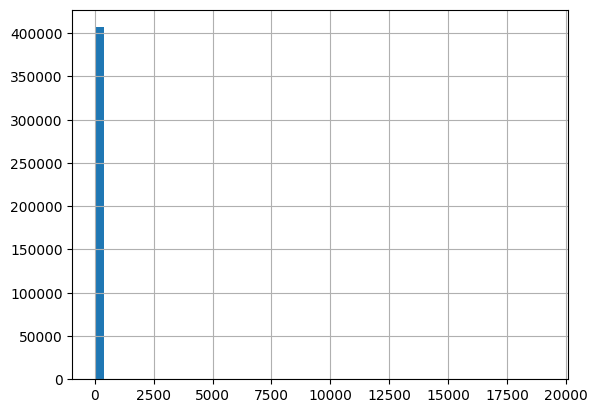

In [13]:
df['Quantity'].hist(bins=50)

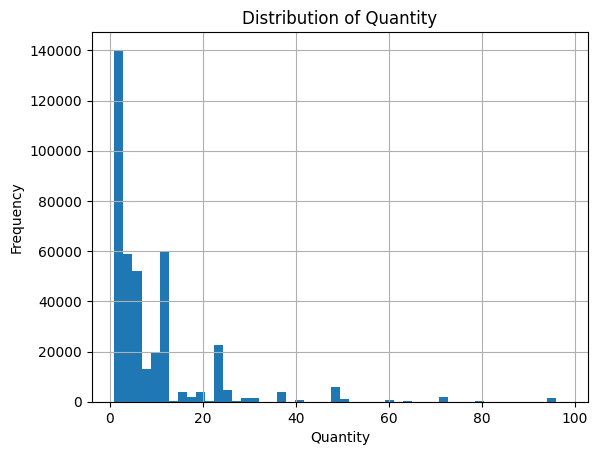

In [14]:
import matplotlib.pyplot as plt

df[df['Quantity'] < 100]['Quantity'].hist(bins=50)
plt.title('Distribution of Quantity')
plt.xlabel('Quantity')
plt.ylabel('Frequency')
plt.show()

In [15]:
df = df[df['Quantity'] <= 100] # here we are capping the values below 100 as a few bulk buyers influence recommendation for normal users.

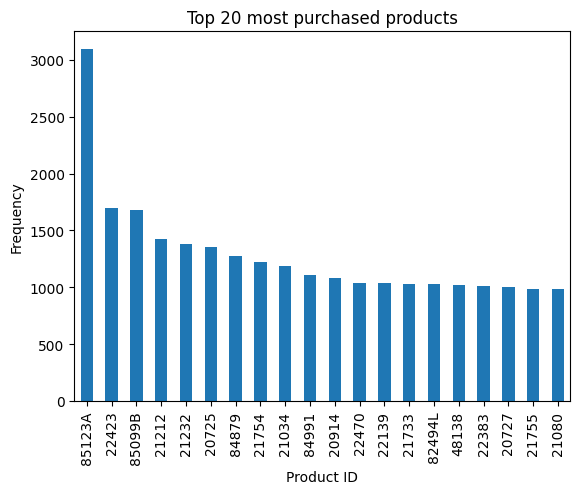

In [16]:
top_prod = df['StockCode'].value_counts().head(20)  #this doesnt show the quant sold of product but shows how many times it appeared in invoices - no. of transactions.
# will show most frequently purchased products.
top_prod.plot(kind='bar')
plt.title('Top 20 most purchased products')
plt.xlabel('Product ID')
plt.ylabel('Frequency')
plt.show()

In [17]:
df['Revenue'] = df['Quantity'] * df['Price']

In [18]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


Text(0, 0.5, 'Revenue')

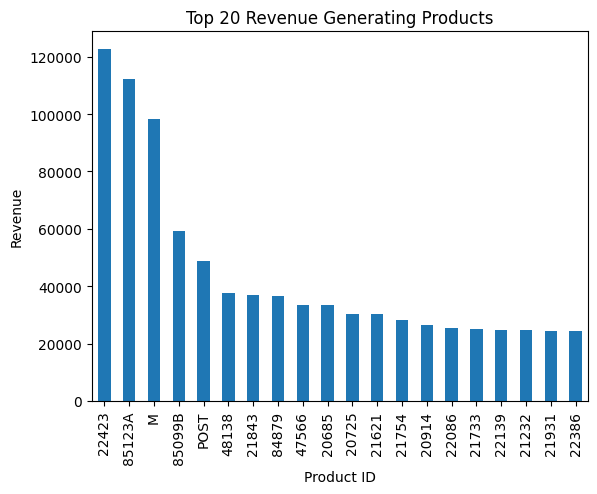

In [19]:
product_rev = df.groupby('StockCode')['Revenue'].sum().sort_values(ascending=False).head(20)
product_rev.plot(kind='bar')
plt.title("Top 20 Revenue Generating Products")
plt.xlabel("Product ID")
plt.ylabel("Revenue")

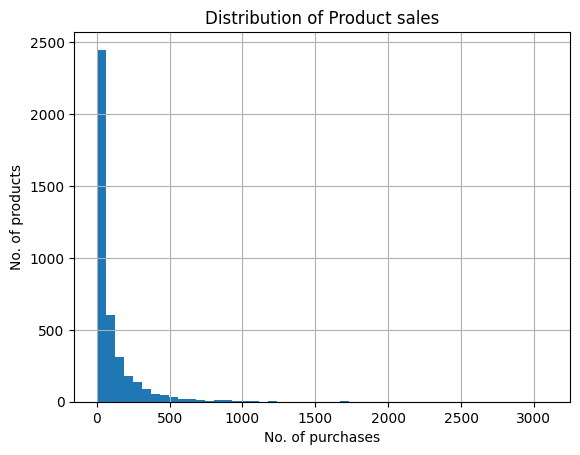

In [20]:
product_sales = df['StockCode'].value_counts()
product_sales.hist(bins=50)
plt.title('Distribution of Product sales')
plt.xlabel('No. of purchases')
plt.ylabel('No. of products')
plt.show()

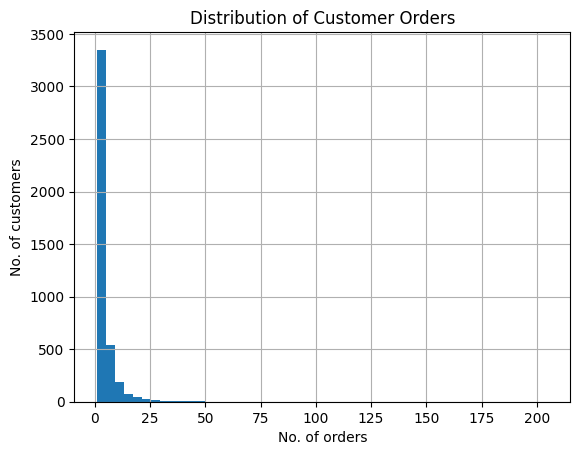

In [21]:
customer_orders = df.groupby('Customer ID')['Invoice'].nunique() #this will group dataset by customers and each customer with their unique invoices showing
#how many orders from a single customer(later used for rfm segmentation).
customer_orders.hist(bins=50)
plt.title('Distribution of Customer Orders')
plt.xlabel('No. of orders')
plt.ylabel('No. of customers')
plt.show()

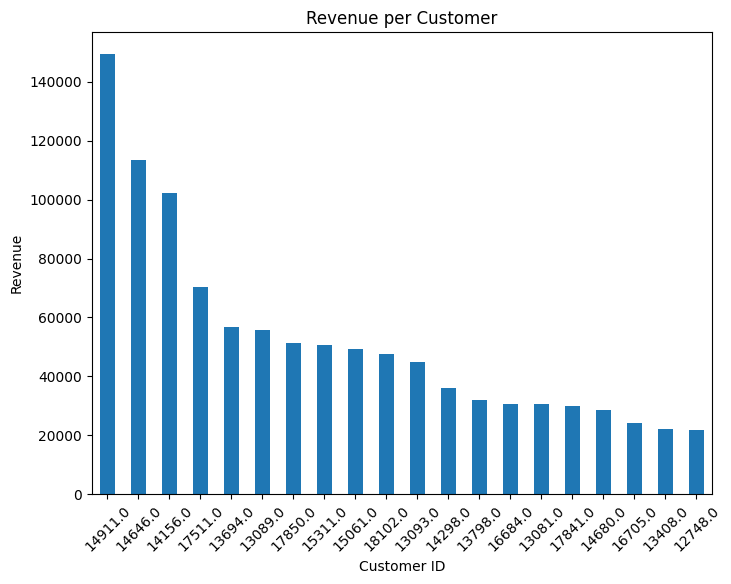

In [22]:
cust_rev = df.groupby('Customer ID')['Revenue'].sum().sort_values(ascending=False)
cust_rev.head(20).plot(kind='bar', figsize = (8,6))
plt.xticks(rotation=45)
plt.title("Revenue per Customer")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")
plt.show()

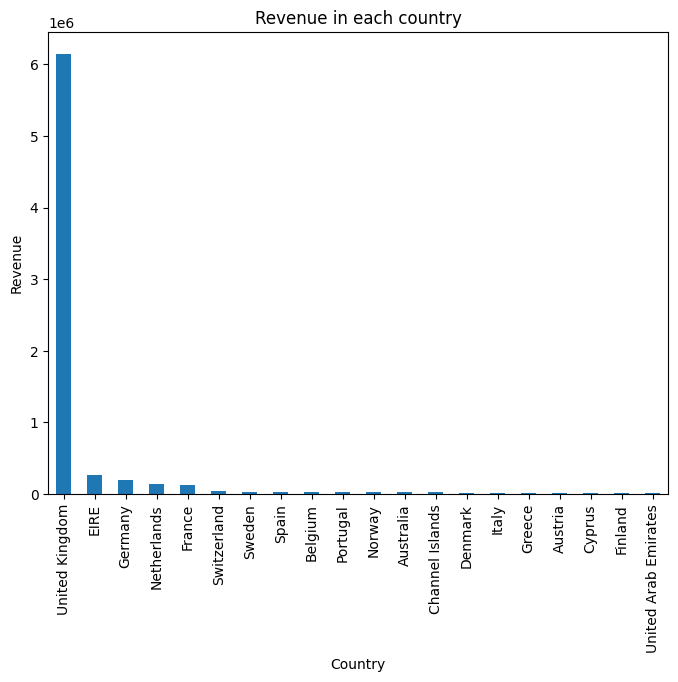

In [23]:
cust_rev = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)
cust_rev.head(20).plot(kind='bar', figsize = (8,6))
plt.title("Revenue in each country")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.show()

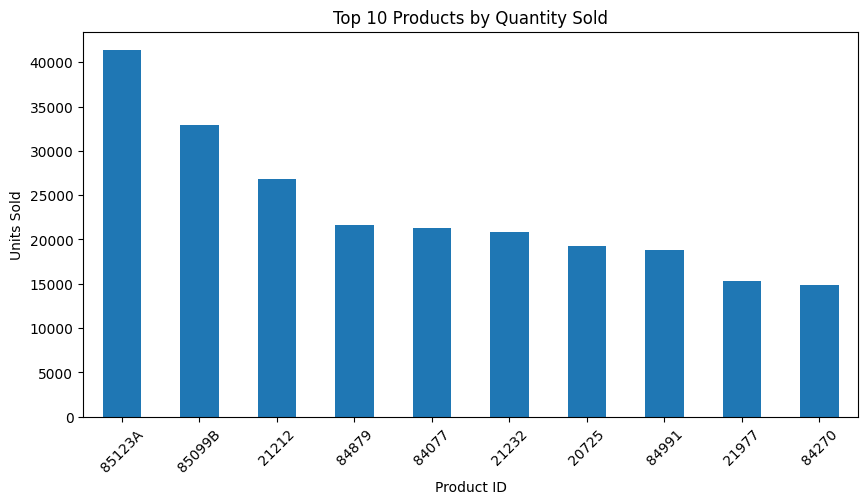

In [24]:
top_products = df.groupby('StockCode')['Quantity'].sum().sort_values(ascending=False)

top_products.head(10).plot(kind='bar', figsize=(10,5))

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Product ID")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.show()

Pareto customer revenue (80/20 rule)

#RFM Customer Segmentation  
This allows us to classify customers into groups like:

VIP customers  
Loyal customers  
Occasional buyers  
Dormant customers  

Recency: How recently a customer purchased - shows if they are active   
Frequency: How frequently they purchase - shows if they are loyal  
Monetary: How much value they generate

In [25]:
df['InvoiceDate'].max()

Timestamp('2010-12-09 20:01:00')

In [26]:
import datetime as dt

referance_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

In [27]:
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate' : lambda x: (referance_date - x.max()).days,
    'Invoice' : 'nunique',
    'Revenue' : 'sum'
})

In [28]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head(10)

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,165,11,372.86
12347.0,3,2,1323.32
12348.0,74,1,222.16
12349.0,43,3,2671.14
12351.0,11,1,300.93
12352.0,11,2,343.80
12353.0,44,1,317.76
12355.0,203,1,488.21
12356.0,16,3,3562.25


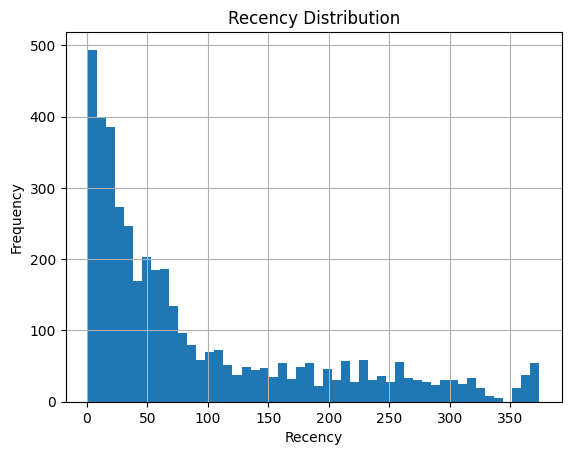

In [29]:
rfm['Recency'].hist(bins=50)
plt.title('Recency Distribution')
plt.xlabel('Recency')
plt.ylabel('Frequency')
plt.show()

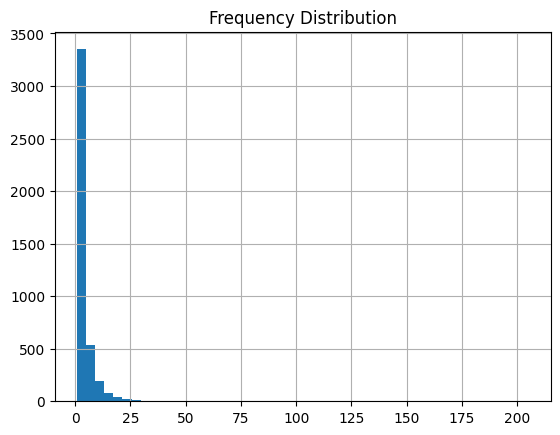

In [30]:
rfm['Frequency'].hist(bins=50)
plt.title("Frequency Distribution")
plt.show()

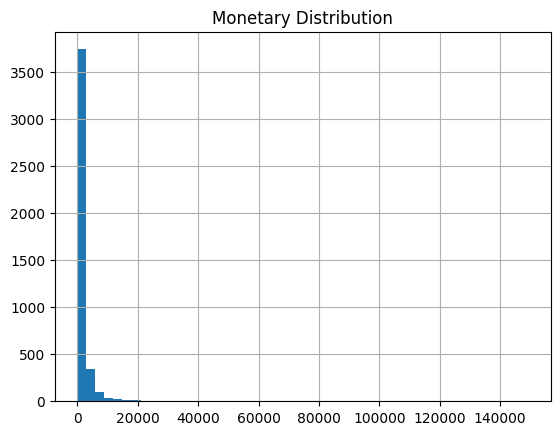

In [31]:
rfm['Monetary'].hist(bins=50)
plt.title("Monetary Distribution")
plt.show()

In [32]:
rfm.describe()

,Recency,Frequency,Monetary
count,4277.000000,4277.000000,4277.000000
mean,91.485855,4.381108,1684.401666
std,97.097656,7.872000,4712.552781
min,1.000000,1.000000,2.950000
25%,18.000000,1.000000,300.120000
50%,53.000000,2.000000,679.800000
75%,137.000000,5.000000,1666.990000
max,374.000000,205.000000,149354.450000


In [33]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])

In [34]:
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[5,4,3,2,1])

In [35]:
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[5,4,3,2,1])

In [36]:
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

In [37]:
rfm.head(10)

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
Customer ID,,,,,,,
12346.0,165,11,372.86,2,1,4,214
12347.0,3,2,1323.32,5,4,2,542
12348.0,74,1,222.16,2,5,5,255
12349.0,43,3,2671.14,3,3,1,331
12351.0,11,1,300.93,5,5,4,554
12352.0,11,2,343.80,5,4,4,544
12353.0,44,1,317.76,3,5,4,354
12355.0,203,1,488.21,1,5,3,153
12356.0,16,3,3562.25,4,3,1,431


In [38]:
rfm['RFM_Score'].value_counts().head(20)

,count
RFM_Score,
511,344
155,197
411,159
145,144
154,112
422,105
144,98
233,98
512,97


/tmp/ipykernel_1320/2168292737.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rfm.groupby('R_score')['Monetary'].mean().plot(kind='bar')


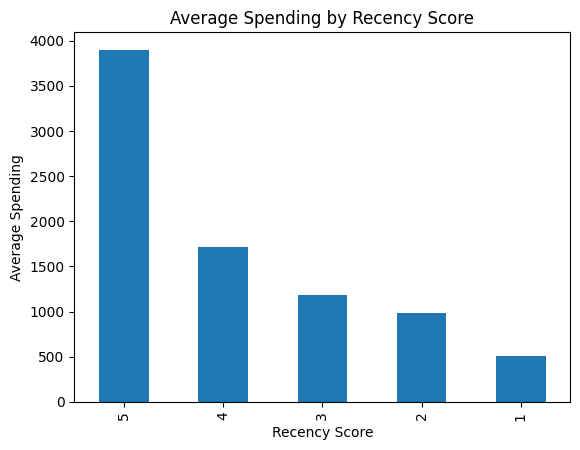

In [39]:
rfm.groupby('R_score')['Monetary'].mean().plot(kind='bar')

plt.title("Average Spending by Recency Score")
plt.xlabel("Recency Score")
plt.ylabel("Average Spending")
plt.show()

In [40]:
def segment_customer(row):
  if row['R_score']>=4 and row['F_score']>=4 and row['M_score']>=4:
    return "VIP"
  if row['R_score']>=4 and row['F_score']>=3:
    return "loyal"
  if row['R_score']>=4:
    return "New"
  if row['R_score'] <=2 and row['M_score']>=4:
    return "High value at risk"
  if row['R_score'] <=2:
    return "At risk"
  else:
    return "Avg"

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

In [41]:
rfm.head(10)

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
Customer ID,,,,,,,,
12346.0,165,11,372.86,2,1,4,214,High value at risk
12347.0,3,2,1323.32,5,4,2,542,loyal
12348.0,74,1,222.16,2,5,5,255,High value at risk
12349.0,43,3,2671.14,3,3,1,331,Avg
12351.0,11,1,300.93,5,5,4,554,VIP
12352.0,11,2,343.80,5,4,4,544,VIP
12353.0,44,1,317.76,3,5,4,354,Avg
12355.0,203,1,488.21,1,5,3,153,At risk
12356.0,16,3,3562.25,4,3,1,431,loyal


In [42]:
rfm['Segment'].value_counts()

,count
Segment,
New,1096
High value at risk,1013
Avg,845
At risk,677
loyal,386
VIP,260


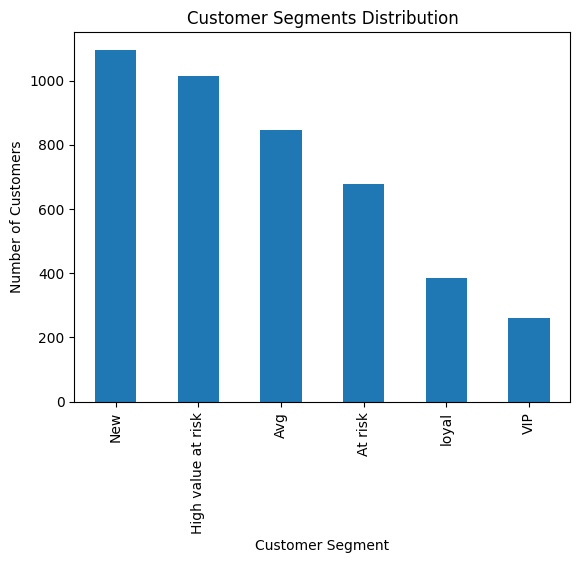

In [43]:
rfm['Segment'].value_counts().plot(kind='bar')

plt.title("Customer Segments Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.show()

In [44]:
rfm['Segment'].value_counts(normalize = True) * 100

,proportion
Segment,
New,25.625438
High value at risk,23.684826
Avg,19.756839
At risk,15.828852
loyal,9.025018
VIP,6.079027


#First Recommender System: Popularity-Based Recommender

In [45]:
popular_products = df.groupby('StockCode')['Quantity'].sum().sort_values(ascending=False)

In [46]:
top_prods = popular_products.head(10)
top_prods

,Quantity
StockCode,
85123A,41357
85099B,32962
21212,26802
84879,21658
84077,21298
21232,20898
20725,19217
84991,18862
21977,15286


In [47]:
def recommend_popular(n=10):
    return popular_products.head(n)

In [48]:
recommend_popular(5) #mainly designed for new users and homepage

,Quantity
StockCode,
85123A,41357
85099B,32962
21212,26802
84879,21658
84077,21298


#Next Recommender system: Item Based Recommender

In [54]:
user_item_matrix = df.pivot_table(
    index = 'Customer ID',
    columns = 'StockCode',
    values = 'Quantity',
    aggfunc = 'sum',
    fill_value=0
)

In [55]:
user_item_matrix #shows which products were bought together and user similarity - useful for similar products recommendation

StockCode,10002,10080,10109,10120,10125,10133,10134,10135,10138,11001,...,ADJUST2,BANK CHARGES,C2,D,M,PADS,POST,SP1002,TEST001,TEST002
Customer ID,,,,,,,,,,,,,,,,,,,,,
12346.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,45,1
12347.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12348.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
12349.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,2,0,0,0
12351.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18283.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
18284.0,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
18285.0,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [56]:
product_user_matrix = user_item_matrix.T
product_user_matrix.head()

Customer ID,12346.0,12347.0,12348.0,12349.0,12351.0,12352.0,12353.0,12355.0,12356.0,12357.0,...,18277.0,18278.0,18279.0,18280.0,18281.0,18283.0,18284.0,18285.0,18286.0,18287.0
StockCode,,,,,,,,,,,,,,,,,,,,,
10002,0,0,0,0,0,0,0,0,0,12,...,0,0,0,0,0,0,0,0,0,0
10080,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10109,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10120,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10125,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [57]:
from sklearn.metrics.pairwise import cosine_similarity

item_similarity = cosine_similarity(product_user_matrix)

In [59]:
item_similarity

array([[1.00000000e+00, 7.76133382e-04, 0.00000000e+00, ...,
        1.40949737e-02, 0.00000000e+00, 0.00000000e+00],
       [7.76133382e-04, 1.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [1.40949737e-02, 0.00000000e+00, 0.00000000e+00, ...,
        1.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 1.00000000e+00, 9.93883735e-01],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 9.93883735e-01, 1.00000000e+00]])